# 04. Evaluasi dan Perbandingan Model

In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
CM_DIR = RESULTS_DIR / "confusion_matrix"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [DATA_DIR, RESULTS_DIR, CM_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\UTS_Data_Mining


In [3]:
CONFIG = {
    "random_seed": 42,
    "batch_size": 64,
    "svm_train_subset": 10000,
    "svm_test_subset": 2000,
    "test_subset": 2000,
    "input_size": 784,
    "num_classes": 10
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["random_seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
nn_results_path = RESULTS_DIR / "nn_results.csv"
svm_results_path = RESULTS_DIR / "svm_results.csv"

if not nn_results_path.exists():
    raise FileNotFoundError(
        f"File {nn_results_path} belum ditemukan. Jalankan notebook 02_train_neural_network.ipynb terlebih dahulu."
    )

if not svm_results_path.exists():
    raise FileNotFoundError(
        f"File {svm_results_path} belum ditemukan. Jalankan notebook 03_train_svm.ipynb terlebih dahulu."
    )

nn_results_df = pd.read_csv(nn_results_path)
svm_results_df = pd.read_csv(svm_results_path)

metrics_results_df = pd.concat(
    [nn_results_df, svm_results_df],
    ignore_index=True
)

metrics_results_df = metrics_results_df.sort_values(
    by=["dataset", "f1_score"],
    ascending=[True, False]
).reset_index(drop=True)

output_path = RESULTS_DIR / "metrics_results.csv"
metrics_results_df.to_csv(output_path, index=False)

display(metrics_results_df)
print("Tabel gabungan disimpan ke:", output_path)

,dataset,model_group,model,configuration,accuracy,precision,recall,f1_score,training_time_seconds,test_size,train_size
0,FashionMNIST,Neural Network,NN-1,"784-128-10, ReLU",0.8810,0.883069,0.881996,0.880162,80.857809,2000,NaN
1,FashionMNIST,Neural Network,NN-2,"784-256-Dropout(0.3)-128-10, ReLU",0.8745,0.878529,0.876508,0.873482,93.764499,2000,NaN
2,FashionMNIST,SVM,SVM RBF,"StandardScaler + SVC(kernel='rbf', C=1.0, gamm...",0.8585,0.855469,0.858164,0.855729,8.501462,2000,10000.0
3,FashionMNIST,SVM,SVM Polynomial,"StandardScaler + SVC(kernel='poly', degree=3, ...",0.8260,0.845570,0.825543,0.831030,10.583226,2000,10000.0
4,FashionMNIST,SVM,SVM Linear,"StandardScaler + SVC(kernel='linear', C=1.0)",0.8015,0.801504,0.800477,0.799463,8.090992,2000,10000.0
5,FashionMNIST,SVM,SVM Sigmoid,"StandardScaler + SVC(kernel='sigmoid', C=1.0, ...",0.7405,0.737254,0.740814,0.736458,5.915385,2000,10000.0
6,MNIST,Neural Network,NN-2,"784-256-Dropout(0.3)-128-10, ReLU",0.9810,0.980873,0.980821,0.980833,93.985983,2000,NaN
7,MNIST,Neural Network,NN-1,"784-128-10, ReLU",0.9755,0.975308,0.975764,0.975381,78.218136,2000,NaN
8,MNIST,SVM,SVM RBF,"StandardScaler + SVC(kernel='rbf', C=1.0, gamm...",0.9375,0.938680,0.936547,0.936879,10.337077,2000,10000.0
9,MNIST,SVM,SVM Linear,"StandardScaler + SVC(kernel='linear', C=1.0)",0.9175,0.917711,0.915582,0.916176,4.115930,2000,10000.0


Tabel gabungan disimpan ke: C:\UTS_Data_Mining\results\metrics_results.csv


In [5]:
summary_columns = [
    "dataset",
    "model_group",
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "training_time_seconds",
    "test_size"
]

display(metrics_results_df[summary_columns])

,dataset,model_group,model,accuracy,precision,recall,f1_score,training_time_seconds,test_size
0,FashionMNIST,Neural Network,NN-1,0.8810,0.883069,0.881996,0.880162,80.857809,2000
1,FashionMNIST,Neural Network,NN-2,0.8745,0.878529,0.876508,0.873482,93.764499,2000
2,FashionMNIST,SVM,SVM RBF,0.8585,0.855469,0.858164,0.855729,8.501462,2000
3,FashionMNIST,SVM,SVM Polynomial,0.8260,0.845570,0.825543,0.831030,10.583226,2000
4,FashionMNIST,SVM,SVM Linear,0.8015,0.801504,0.800477,0.799463,8.090992,2000
5,FashionMNIST,SVM,SVM Sigmoid,0.7405,0.737254,0.740814,0.736458,5.915385,2000
6,MNIST,Neural Network,NN-2,0.9810,0.980873,0.980821,0.980833,93.985983,2000
7,MNIST,Neural Network,NN-1,0.9755,0.975308,0.975764,0.975381,78.218136,2000
8,MNIST,SVM,SVM RBF,0.9375,0.938680,0.936547,0.936879,10.337077,2000
9,MNIST,SVM,SVM Linear,0.9175,0.917711,0.915582,0.916176,4.115930,2000


In [6]:
for dataset_name in metrics_results_df["dataset"].unique():
    print("=" * 80)
    print(f"Ranking model untuk dataset: {dataset_name}")
    display(
        metrics_results_df[metrics_results_df["dataset"] == dataset_name]
        .sort_values(by="f1_score", ascending=False)
        [summary_columns]
    )

Ranking model untuk dataset: FashionMNIST


,dataset,model_group,model,accuracy,precision,recall,f1_score,training_time_seconds,test_size
0,FashionMNIST,Neural Network,NN-1,0.8810,0.883069,0.881996,0.880162,80.857809,2000
1,FashionMNIST,Neural Network,NN-2,0.8745,0.878529,0.876508,0.873482,93.764499,2000
2,FashionMNIST,SVM,SVM RBF,0.8585,0.855469,0.858164,0.855729,8.501462,2000
3,FashionMNIST,SVM,SVM Polynomial,0.8260,0.845570,0.825543,0.831030,10.583226,2000
4,FashionMNIST,SVM,SVM Linear,0.8015,0.801504,0.800477,0.799463,8.090992,2000
5,FashionMNIST,SVM,SVM Sigmoid,0.7405,0.737254,0.740814,0.736458,5.915385,2000


Ranking model untuk dataset: MNIST


,dataset,model_group,model,accuracy,precision,recall,f1_score,training_time_seconds,test_size
6,MNIST,Neural Network,NN-2,0.9810,0.980873,0.980821,0.980833,93.985983,2000
7,MNIST,Neural Network,NN-1,0.9755,0.975308,0.975764,0.975381,78.218136,2000
8,MNIST,SVM,SVM RBF,0.9375,0.938680,0.936547,0.936879,10.337077,2000
9,MNIST,SVM,SVM Linear,0.9175,0.917711,0.915582,0.916176,4.115930,2000
10,MNIST,SVM,SVM Polynomial,0.9060,0.916363,0.905464,0.907456,20.366378,2000
11,MNIST,SVM,SVM Sigmoid,0.9065,0.906112,0.904871,0.905135,5.884655,2000


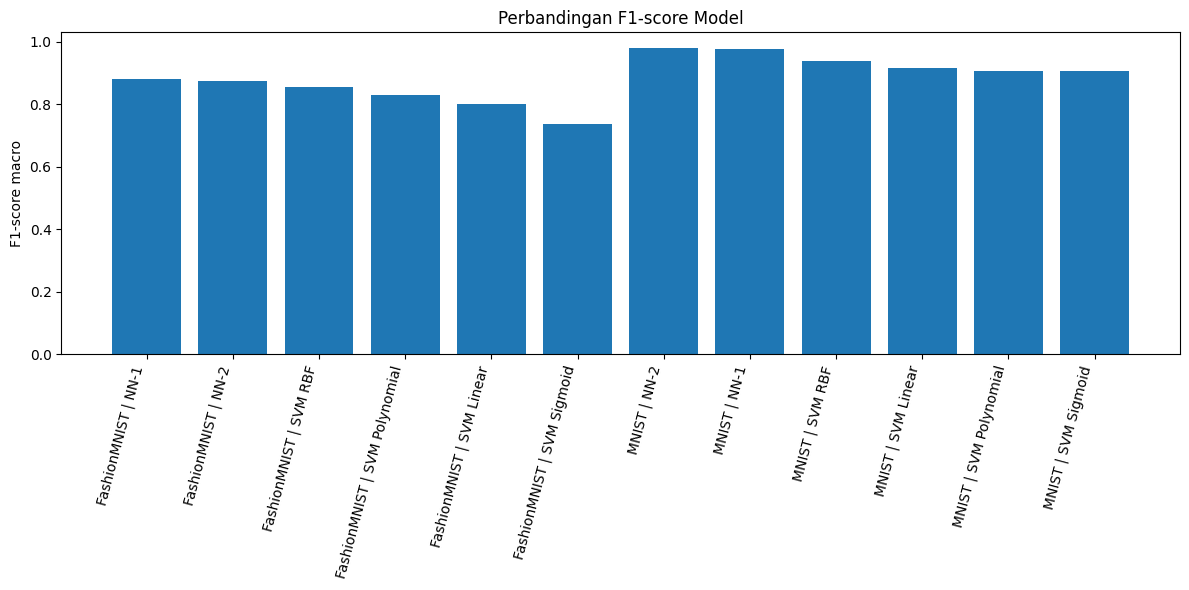

In [7]:
plt.figure(figsize=(12, 6))

plot_df = metrics_results_df.copy()
plot_df["label"] = plot_df["dataset"] + " | " + plot_df["model"]

plt.bar(plot_df["label"], plot_df["f1_score"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("F1-score macro")
plt.title("Perbandingan F1-score Model")
plt.tight_layout()
plt.show()

In [8]:
transform = transforms.ToTensor()

dataset_objects = {
    "MNIST": {
        "train": datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform),
        "test": datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform),
        "classes": [str(i) for i in range(10)],
        "model_file": "best_nn_mnist.pth"
    },
    "FashionMNIST": {
        "train": datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform),
        "test": datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform),
        "classes": [
            "T-shirt/top",
            "Trouser",
            "Pullover",
            "Dress",
            "Coat",
            "Sandal",
            "Shirt",
            "Sneaker",
            "Bag",
            "Ankle boot"
        ],
        "model_file": "best_nn_fashion_mnist.pth"
    }
}

In [9]:
def fixed_indices(dataset_length, subset_size, seed=42):
    subset_size = min(subset_size, dataset_length)
    rng = np.random.RandomState(seed)
    return rng.choice(dataset_length, size=subset_size, replace=False)


def dataset_to_numpy(dataset, indices):
    X = []
    y = []

    for idx in indices:
        image, label = dataset[idx]
        X.append(image.view(-1).numpy())
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y


def prepare_svm_data(train_dataset, test_dataset):
    train_indices = fixed_indices(
        len(train_dataset),
        CONFIG["svm_train_subset"],
        seed=CONFIG["random_seed"]
    )

    test_indices = fixed_indices(
        len(test_dataset),
        CONFIG["svm_test_subset"],
        seed=CONFIG["random_seed"]
    )

    X_train, y_train = dataset_to_numpy(train_dataset, train_indices)
    X_test, y_test = dataset_to_numpy(test_dataset, test_indices)

    return X_train, y_train, X_test, y_test


def build_svm_model(kernel):
    if kernel == "poly":
        svm = SVC(kernel=kernel, degree=3, C=1.0, gamma="scale")
    else:
        svm = SVC(kernel=kernel, C=1.0, gamma="scale")

    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", svm)
    ])

In [10]:
class NN1_SimpleMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


class NN2_DeeperMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


model_class_map = {
    "NN-1": NN1_SimpleMLP,
    "NN-2": NN2_DeeperMLP
}


def fixed_subset(dataset, subset_size, seed=42):
    subset_size = min(subset_size, len(dataset))
    indices = fixed_indices(len(dataset), subset_size, seed)
    return Subset(dataset, indices)


def predict_nn(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [11]:
def save_confusion_matrix(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(ax=ax, cmap=None, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()

    output_file = CM_DIR / filename
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion matrix disimpan ke:", output_file)

Confusion matrix untuk dataset: MNIST


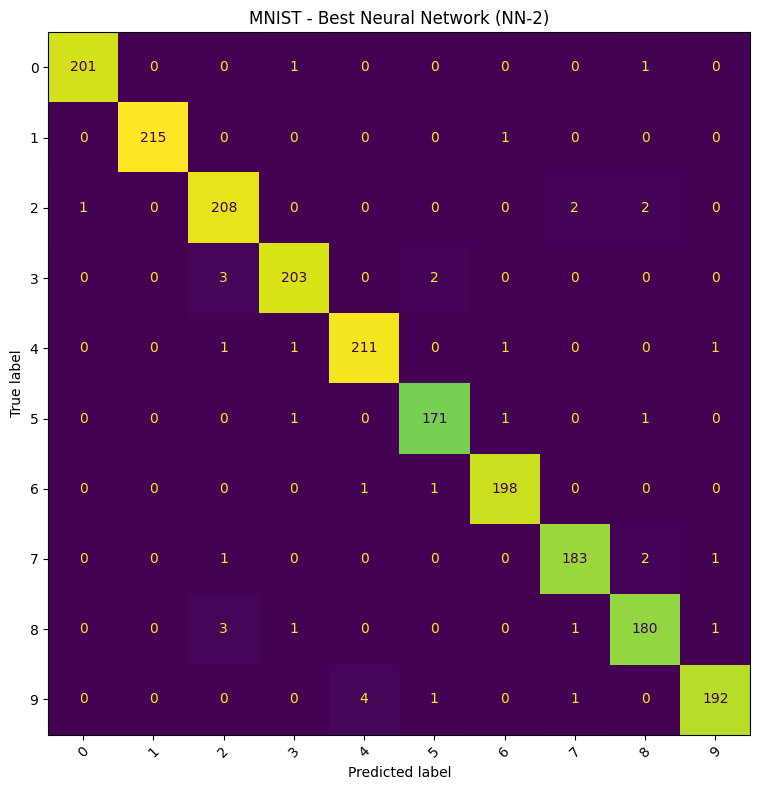

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\mnist_best_neural_network_cm.png
Melatih ulang SVM RBF untuk confusion matrix...


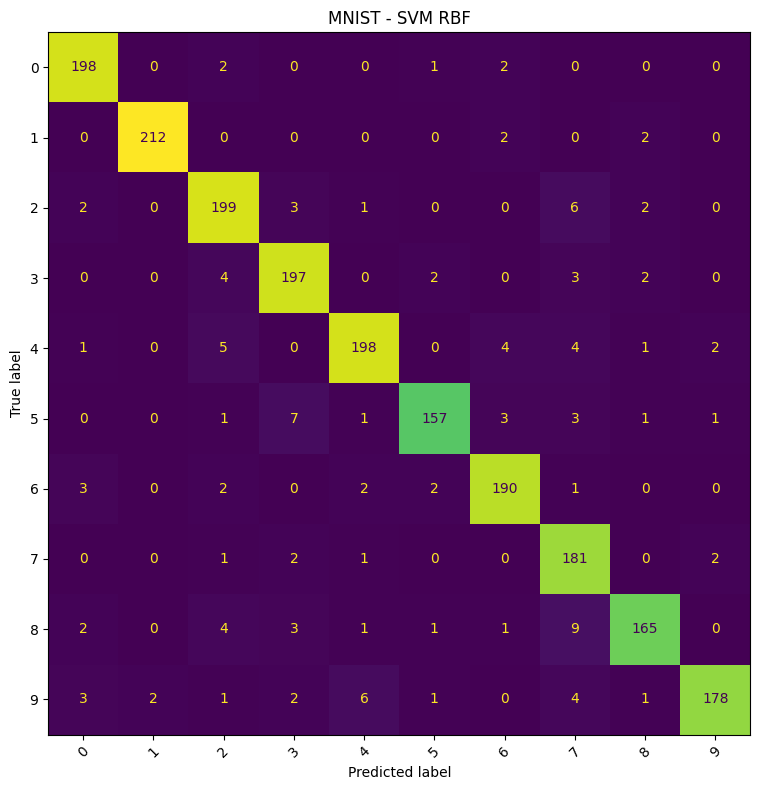

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\mnist_svm_rbf_cm.png
Melatih ulang SVM Sigmoid untuk confusion matrix...


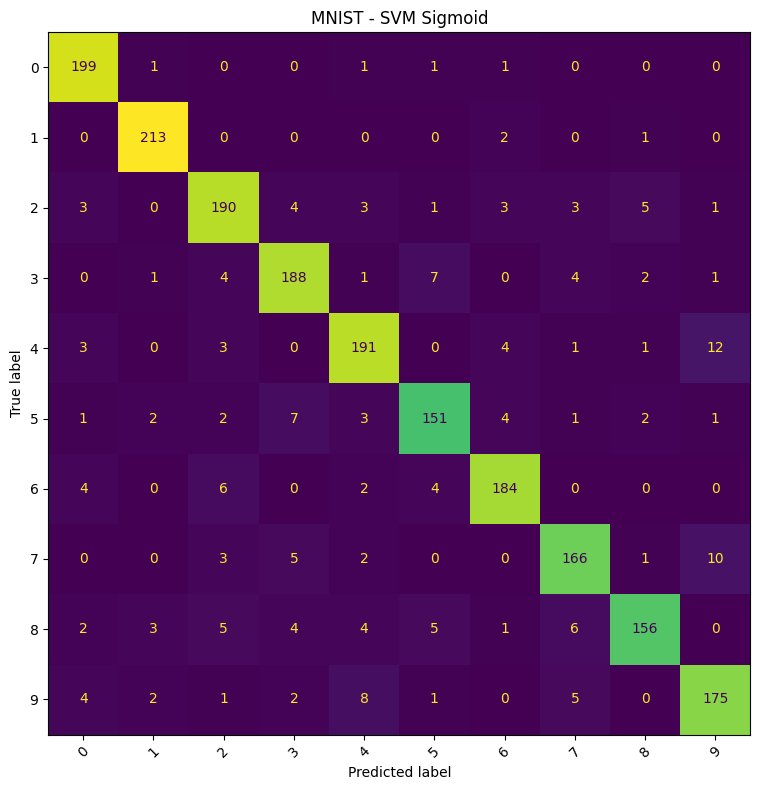

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\mnist_svm_sigmoid_cm.png
Confusion matrix untuk dataset: FashionMNIST


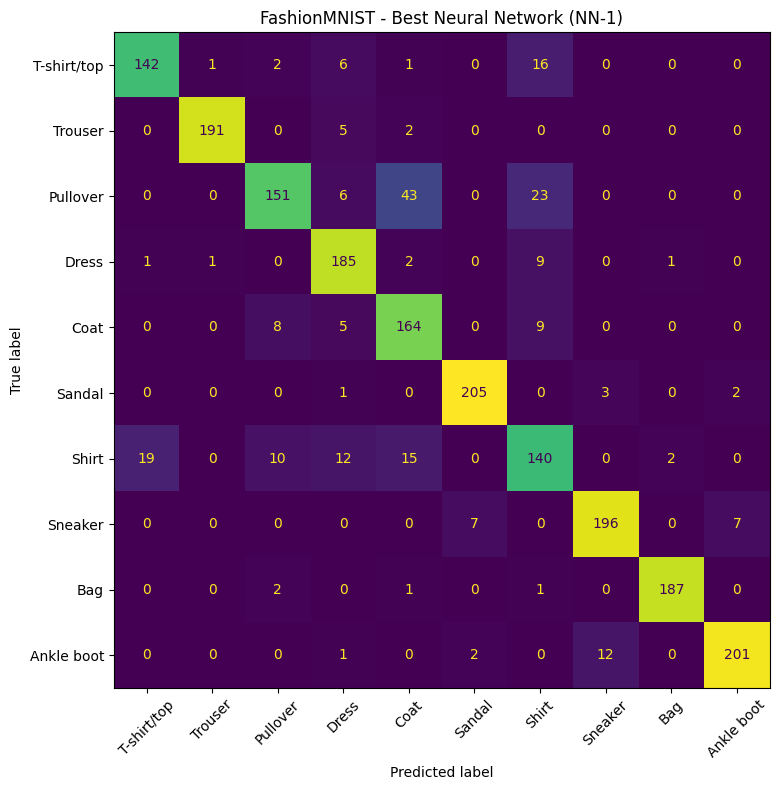

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\fashionmnist_best_neural_network_cm.png
Melatih ulang SVM RBF untuk confusion matrix...


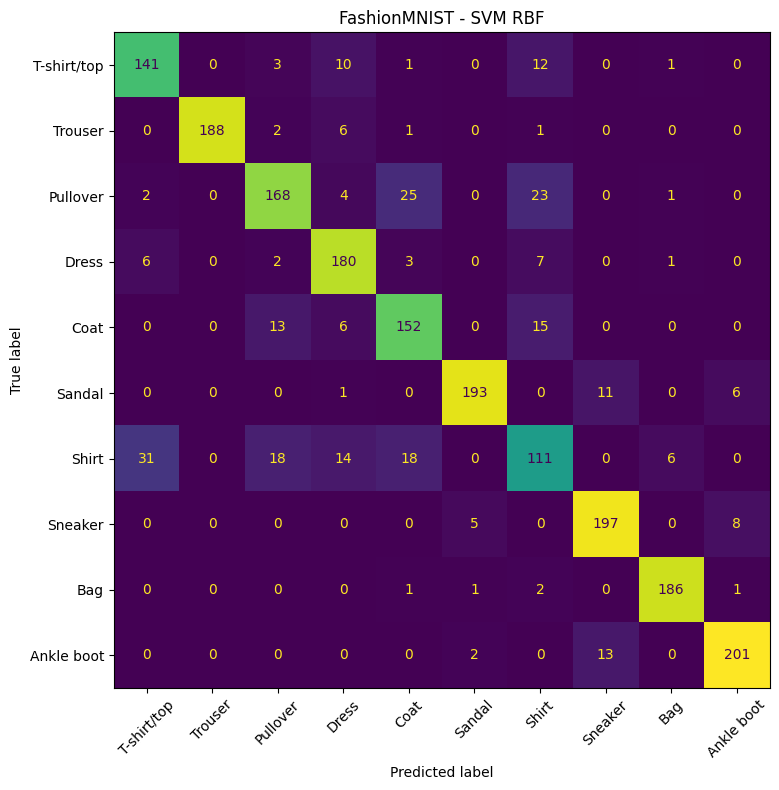

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\fashionmnist_svm_rbf_cm.png
Melatih ulang SVM Sigmoid untuk confusion matrix...


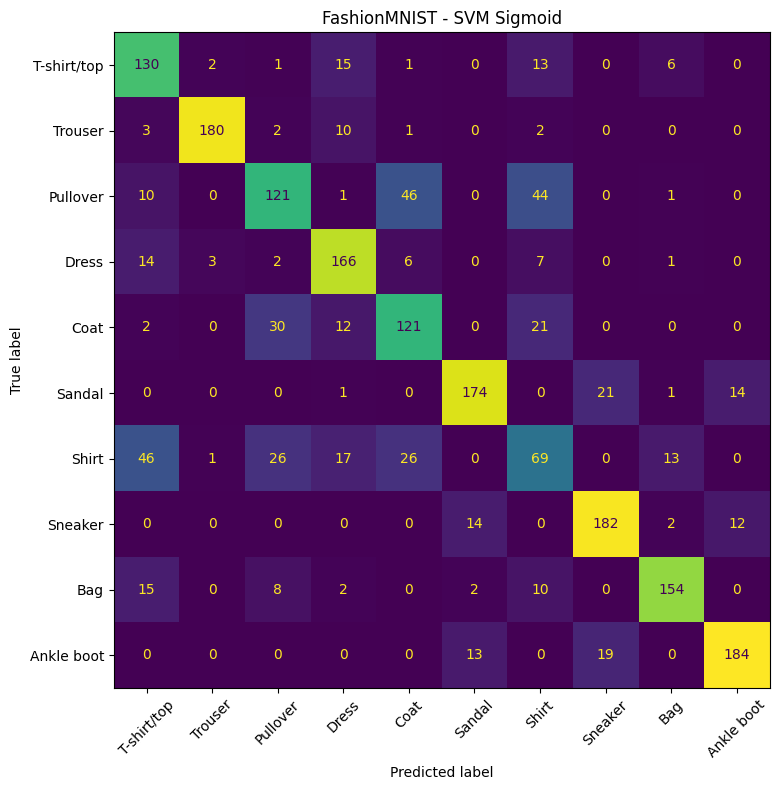

Confusion matrix disimpan ke: C:\UTS_Data_Mining\results\confusion_matrix\fashionmnist_svm_sigmoid_cm.png


In [12]:
svm_kernel_map = {
    "SVM Linear": "linear",
    "SVM Polynomial": "poly",
    "SVM RBF": "rbf",
    "SVM Sigmoid": "sigmoid"
}

for dataset_name, dataset_data in dataset_objects.items():
    print("=" * 80)
    print(f"Confusion matrix untuk dataset: {dataset_name}")

    dataset_metrics = metrics_results_df[
        metrics_results_df["dataset"] == dataset_name
    ].copy()

    # 1. Confusion matrix untuk Neural Network terbaik
    nn_metrics = dataset_metrics[
        dataset_metrics["model_group"] == "Neural Network"
    ].sort_values(by="f1_score", ascending=False)

    if len(nn_metrics) > 0:
        best_nn_name = nn_metrics.iloc[0]["model"]
        checkpoint_path = MODELS_DIR / dataset_data["model_file"]

        if checkpoint_path.exists():
            checkpoint = torch.load(checkpoint_path, map_location=device)
            saved_model_name = checkpoint["model_name"]

            nn_class = model_class_map[saved_model_name]
            nn_model = nn_class(
                input_size=CONFIG["input_size"],
                num_classes=CONFIG["num_classes"]
            ).to(device)

            nn_model.load_state_dict(checkpoint["model_state_dict"])

            test_subset = fixed_subset(
                dataset_data["test"],
                CONFIG["test_subset"],
                seed=CONFIG["random_seed"]
            )

            test_loader = DataLoader(
                test_subset,
                batch_size=CONFIG["batch_size"],
                shuffle=False,
                num_workers=0
            )

            y_true_nn, y_pred_nn = predict_nn(nn_model, test_loader, device)

            save_confusion_matrix(
                y_true=y_true_nn,
                y_pred=y_pred_nn,
                class_names=dataset_data["classes"],
                title=f"{dataset_name} - Best Neural Network ({saved_model_name})",
                filename=f"{dataset_name.lower()}_best_neural_network_cm.png"
            )
        else:
            print(f"Checkpoint tidak ditemukan: {checkpoint_path}")

    # 2. Confusion matrix untuk SVM terbaik dan SVM sigmoid sebagai pembanding
    svm_metrics = dataset_metrics[
        dataset_metrics["model_group"] == "SVM"
    ].sort_values(by="f1_score", ascending=False)

    if len(svm_metrics) > 0:
        selected_svm_models = [svm_metrics.iloc[0]["model"]]

        if "SVM Sigmoid" not in selected_svm_models:
            selected_svm_models.append("SVM Sigmoid")

        X_train, y_train, X_test, y_test = prepare_svm_data(
            dataset_data["train"],
            dataset_data["test"]
        )

        for svm_model_name in selected_svm_models:
            if svm_model_name not in svm_kernel_map:
                continue

            kernel = svm_kernel_map[svm_model_name]
            print(f"Melatih ulang {svm_model_name} untuk confusion matrix...")

            svm_model = build_svm_model(kernel)
            svm_model.fit(X_train, y_train)
            y_pred_svm = svm_model.predict(X_test)

            safe_name = svm_model_name.lower().replace(" ", "_")
            save_confusion_matrix(
                y_true=y_test,
                y_pred=y_pred_svm,
                class_names=dataset_data["classes"],
                title=f"{dataset_name} - {svm_model_name}",
                filename=f"{dataset_name.lower()}_{safe_name}_cm.png"
            )

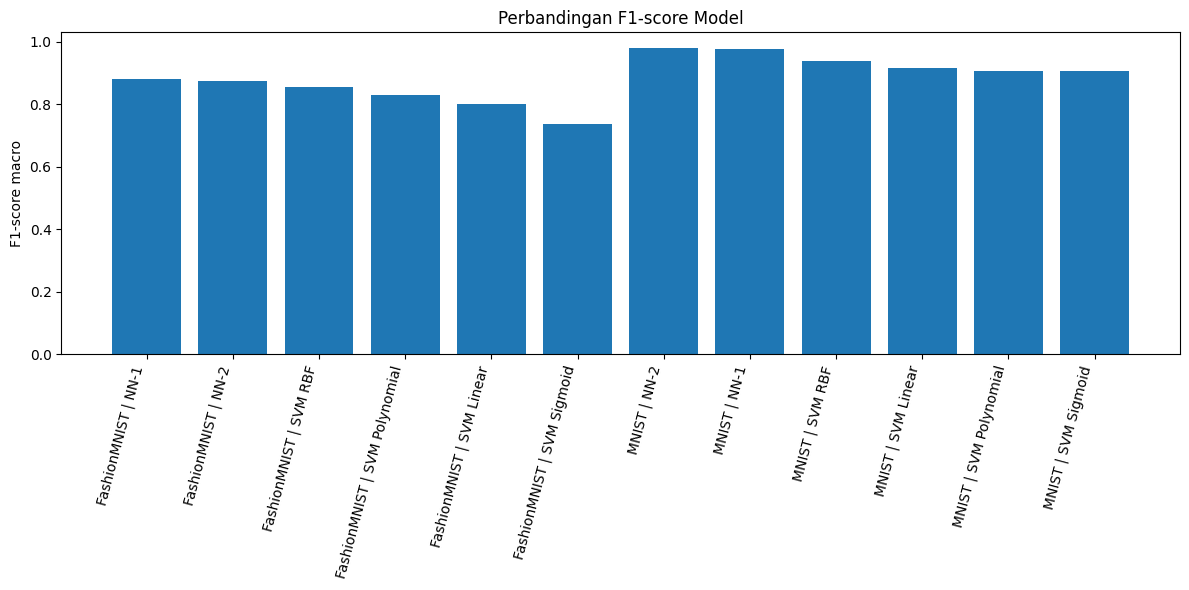

Grafik disimpan ke: C:\UTS_Data_Mining\results\comparison_chart.png


In [ ]:
plt.figure(figsize=(12, 6))

plot_df = metrics_results_df.copy()
plot_df["label"] = plot_df["dataset"] + " | " + plot_df["model"]

plt.bar(plot_df["label"], plot_df["f1_score"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("F1-score macro")
plt.title("Perbandingan F1-score Model")

plt.tight_layout()

# SAVE GAMBAR
chart_path = RESULTS_DIR / "comparison_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Grafik disimpan ke:", chart_path)    